In [6]:
# ── Install / upgrade packages ────────────────────────────────────────────────
# Run this cell once; restart kernel if prompted
import subprocess, sys
pkgs = ['yfinance', 'pandas', 'numpy', 'matplotlib', 'seaborn',
        'scipy', 'statsmodels', 'ipywidgets', 'plotly']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + pkgs)
print('✅ All packages installed/verified.')

✅ All packages installed/verified.


In [7]:
import yfinance          as yf
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import matplotlib.gridspec as gridspec
import seaborn           as sns
from   scipy             import stats
from   statsmodels.regression.linear_model import OLS
from   statsmodels.tools import add_constant
import ipywidgets        as widgets
from   IPython.display   import display, HTML
import warnings, datetime, textwrap
warnings.filterwarnings('ignore')

# ── JupyterLab dark theme ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0d1117',
    'axes.facecolor'    : '#161b22',
    'axes.edgecolor'    : '#30363d',
    'axes.labelcolor'   : '#c9d1d9',
    'xtick.color'       : '#8b949e',
    'ytick.color'       : '#8b949e',
    'text.color'        : '#c9d1d9',
    'grid.color'        : '#21262d',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.6,
    'legend.facecolor'  : '#161b22',
    'legend.edgecolor'  : '#30363d',
    'figure.dpi'        : 120,
    'font.size'         : 10,
})

# Colour palette
C = dict(
    blue   = '#58a6ff',
    green  = '#3fb950',
    red    = '#f85149',
    yellow = '#e3b341',
    purple = '#bc8cff',
    orange = '#d29922',
    white  = '#c9d1d9',
    grey   = '#484f58',
)

print('✅ Imports complete. JupyterLab theme applied.')

✅ Imports complete. JupyterLab theme applied.


In [42]:
TICKER      = 'EGP'           # EastGroup Properties
BENCHMARK   = 'VNQ'           # Vanguard Real Estate ETF  ← REIT-appropriate benchmark
START_DATE  = '2020-01-01'
END_DATE    = datetime.date.today().strftime('2026-02-20')

# ── Key events to study ────────────────────────────────────────────────────────
# Add / remove rows as needed: 'YYYY-MM-DD': 'Short label'
EVENTS = {
    '2020-02-19': 'Pre-COVID Peak',
    '2025-04-02': 'Trump announced Tariffs',
    '2026-02-05': 'Earnings Call',
    '2026-02-20': 'Supreme Court ruled out Tariffs'
}

# ── Event Study Windows ────────────────────────────────────────────────────────
PRE_WINDOW   = 2    # trading days before event
POST_WINDOW  = 2   # trading days after event
ESTIM_WINDOW = 2   # estimation window (days before pre-event window)

# ── Monte Carlo ────────────────────────────────────────────────────────────────
N_SIMULATIONS   = 10_000
FORECAST_DAYS   = 252          # ~1 trading year
INITIAL_PRICE   = None         # None = use latest close automatically
VaR_LEVELS      = [0.90, 0.95, 0.99]

print(f'  Ticker     : {TICKER} (EastGroup Properties)')
print(f'  Benchmark  : {BENCHMARK} (Vanguard Real Estate ETF)')
print(f'  Period     : {START_DATE}  →  {END_DATE}')
print(f'  Events     : {len(EVENTS)}')
print(f'  MC Sims    : {N_SIMULATIONS:,}  |  Horizon: {FORECAST_DAYS} trading days')

  Ticker     : EGP (EastGroup Properties)
  Benchmark  : VNQ (Vanguard Real Estate ETF)
  Period     : 2020-01-01  →  2026-02-20
  Events     : 4
  MC Sims    : 10,000  |  Horizon: 252 trading days


In [44]:
# ── Download data ──────────────────────────────────────────────────────────────
print('Downloading price data...')
raw_egp = yf.download(TICKER,    start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)
raw_vnq = yf.download(BENCHMARK, start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)

egp_close = raw_egp['Close'].squeeze().dropna()
vnq_close = raw_vnq['Close'].squeeze().dropna()

# Log returns
egp_ret = np.log(egp_close / egp_close.shift(1)).dropna()
vnq_ret = np.log(vnq_close / vnq_close.shift(1)).dropna()

# Align on common trading dates
common  = egp_ret.index.intersection(vnq_ret.index)
egp_ret = egp_ret.loc[common]
vnq_ret = vnq_ret.loc[common]

if INITIAL_PRICE is None:
    INITIAL_PRICE = float(egp_close.iloc[-1])

print(f'✅ {TICKER}  — {len(egp_close):,} observations  |  Last close = ${INITIAL_PRICE:.2f}')
print(f'✅ {BENCHMARK} — {len(vnq_close):,} observations  |  Last close = ${float(vnq_close.iloc[-1]):.2f}')
print(f'   Common trading days : {len(common):,}')
print(f'   Date range          : {common[0].date()} → {common[-1].date()}')

✅ EGP  — 1,541 observations  |  Last close = $190.64
✅ VNQ — 1,541 observations  |  Last close = $94.17
   Common trading days : 1,540
   Date range          : 2020-01-03 → 2026-02-19


In [46]:
def run_event_study(event_date_str, stock_ret, bench_ret,
                    pre=PRE_WINDOW, post=POST_WINDOW, estim=ESTIM_WINDOW):
    """
    Market-model event study for a single event date.
    Returns dict with AR, CAR, t-stats, OLS params, or None if insufficient data.
    """
    all_dates = stock_ret.index
    event_ts  = pd.Timestamp(event_date_str)
    candidates = all_dates[all_dates >= event_ts]
    if len(candidates) == 0:
        return None
    event_ts = candidates[0]          # snap to nearest trading day
    pos      = all_dates.get_loc(event_ts)

    es = pos - pre - estim            # estimation start
    ee = pos - pre                    # estimation end
    ws = pos - pre                    # event-window start
    we = pos + post + 1               # event-window end

    if es < 0 or we > len(all_dates):
        return None

    # OLS estimation
    Y      = stock_ret.iloc[es:ee].values
    X      = add_constant(bench_ret.iloc[es:ee].values)
    model  = OLS(Y, X).fit()
    alpha, beta = model.params
    sigma  = np.std(model.resid, ddof=2)

    # Event window
    ev_dates   = all_dates[ws:we]
    actual_r   = stock_ret.iloc[ws:we].values
    bench_r    = bench_ret.iloc[ws:we].values
    expected_r = alpha + beta * bench_r
    AR         = actual_r - expected_r
    CAR        = np.cumsum(AR)
    t_stats    = AR / sigma if sigma > 0 else np.zeros_like(AR)

    # Benchmark CAR (raw)
    bench_CAR  = np.cumsum(bench_r)

    return {
        'event_date'   : event_ts,
        'alpha'        : alpha,
        'beta'         : beta,
        'r_squared'    : model.rsquared,
        'sigma'        : sigma,
        'relative_days': np.arange(-pre, post + 1),
        'ev_dates'     : ev_dates,
        'actual_ret'   : actual_r,
        'expected_ret' : expected_r,
        'bench_ret'    : bench_r,
        'AR'           : AR,
        'CAR'          : CAR,
        'bench_CAR'    : bench_CAR,
        't_stats'      : t_stats,
        'CAR_total'    : float(CAR[-1]),
        'AR_day0'      : float(AR[pre]),
        't_day0'       : float(t_stats[pre]),
    }

# ── Run all events ─────────────────────────────────────────────────────────────
results, skipped = {}, []
print(f'  Running event study  ({PRE_WINDOW} pre / {POST_WINDOW} post / {ESTIM_WINDOW} estim)\n')
for date_str, label in EVENTS.items():
    r = run_event_study(date_str, egp_ret, vnq_ret)
    if r:
        results[label] = r
        sig = '***' if abs(r['t_day0'])>2.576 else ('**' if abs(r['t_day0'])>1.96 else ('*' if abs(r['t_day0'])>1.645 else '  '))
        direction = '📈' if r['CAR_total'] > 0 else '📉'
        print(f'  ✅ {date_str}  {label:<38}  β={r["beta"]:+.3f}  '
              f'AR₀={r["AR_day0"]*100:+.2f}%{sig}  CAR={r["CAR_total"]*100:+.2f}% {direction}')
    else:
        skipped.append((date_str, label))
        print(f'  ⚠️  {date_str}  {label:<38}  Skipped (insufficient data)')

print(f'\n✅ Done — {len(results)} events processed, {len(skipped)} skipped')

  Running event study  (2 pre / 2 post / 2 estim)

  ✅ 2020-02-19  Pre-COVID Peak                          β=+97.032  AR₀=+188.06%    CAR=+186.39% 📈
  ✅ 2025-04-02  Trump announced Tariffs                 β=+3.182  AR₀=-2.39%    CAR=+10.37% 📈
  ✅ 2026-02-05  Earnings Call                           β=+0.741  AR₀=+2.88%    CAR=+2.62% 📈
  ⚠️  2026-02-20  Supreme Court ruled out Tariffs         Skipped (insufficient data)

✅ Done — 3 events processed, 1 skipped


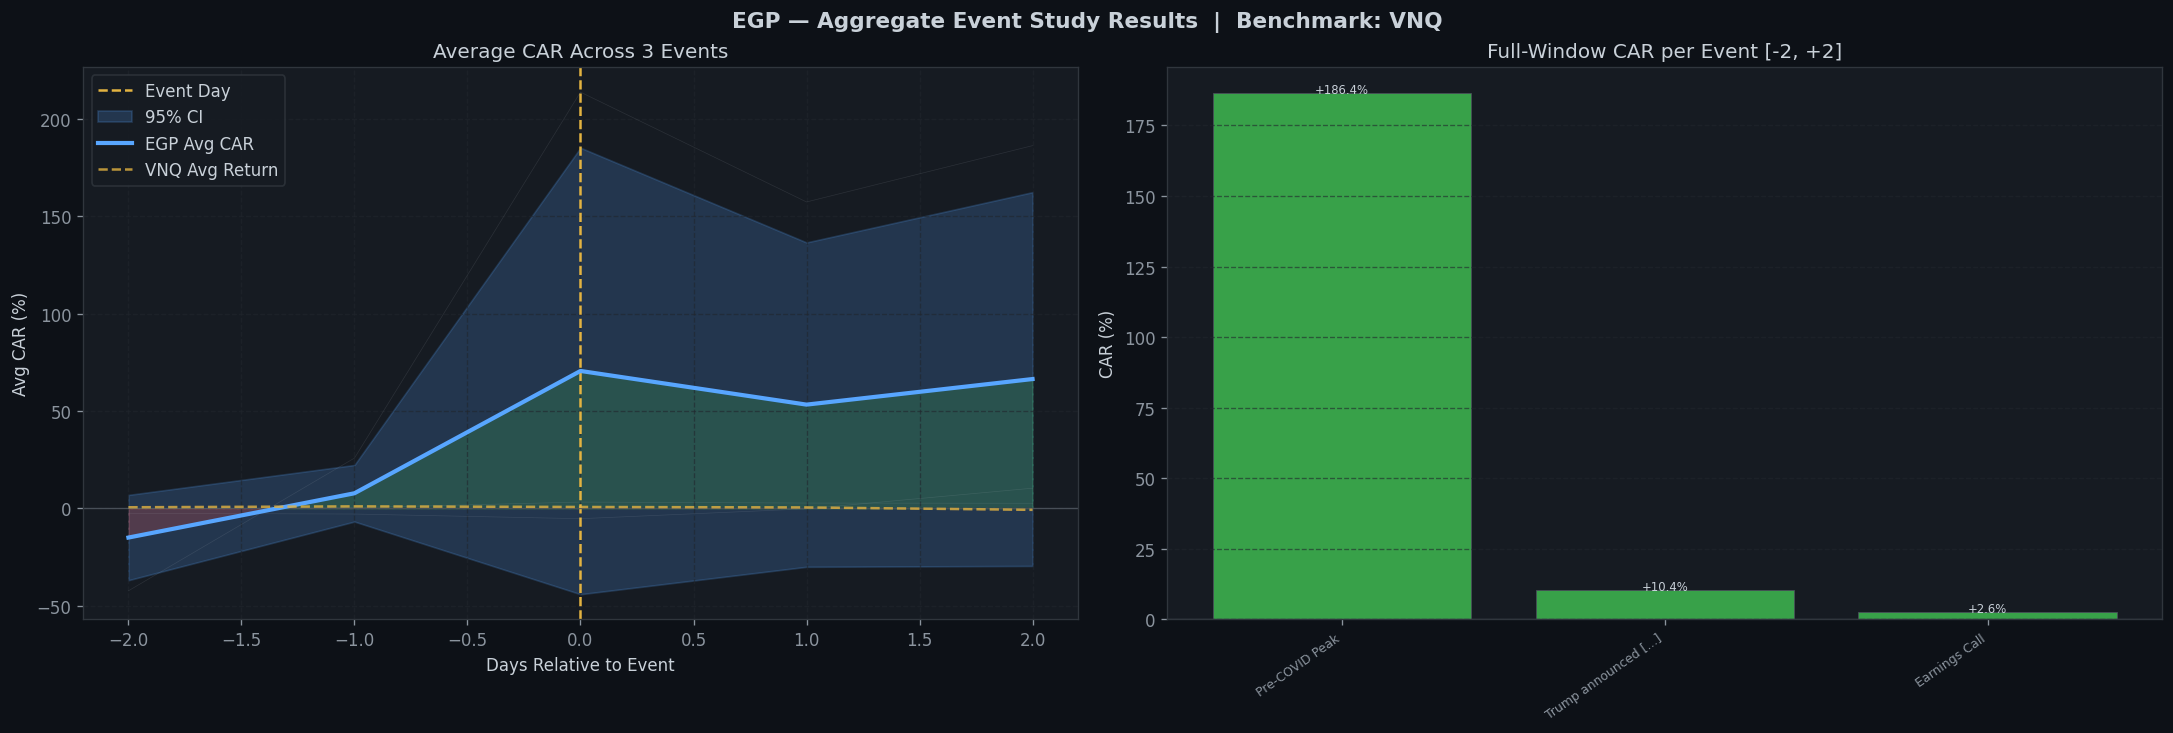

In [48]:
all_cars  = np.array([r['CAR']       for r in results.values()])  # (n_events, window)
all_bcars = np.array([r['bench_CAR'] for r in results.values()])
avg_car   = np.mean(all_cars,  axis=0) * 100
avg_bcar  = np.mean(all_bcars, axis=0) * 100
ci95      = 1.96 * np.std(all_cars, axis=0) * 100 / np.sqrt(len(results))
days      = np.arange(-PRE_WINDOW, POST_WINDOW + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
fig.suptitle(f'{TICKER} — Aggregate Event Study Results  |  Benchmark: {BENCHMARK}',
             fontsize=13, fontweight='bold', color=C['white'])

# ── Average CAR plot ──────────────────────────────────────────────────────────
ax1.axvline(0, color=C['yellow'], lw=1.5, linestyle='--', label='Event Day')
ax1.axhline(0, color=C['grey'],   lw=0.8)
ax1.fill_between(days, avg_car - ci95, avg_car + ci95, alpha=0.2,
                 color=C['blue'], label='95% CI')
ax1.fill_between(days, avg_car, 0, where=(avg_car >= 0),
                 alpha=0.22, color=C['green'], interpolate=True)
ax1.fill_between(days, avg_car, 0, where=(avg_car <  0),
                 alpha=0.22, color=C['red'],   interpolate=True)

# Individual event traces (faint)
for r in results.values():
    ax1.plot(days, r['CAR']*100, color=C['white'], lw=0.4, alpha=0.12)

ax1.plot(days, avg_car,  color=C['blue'],   lw=2.5, label=f'{TICKER} Avg CAR')
ax1.plot(days, avg_bcar, color=C['yellow'], lw=1.5, linestyle='--',
         alpha=0.8, label=f'{BENCHMARK} Avg Return')
ax1.set_title(f'Average CAR Across {len(results)} Events', color=C['white'])
ax1.set_xlabel('Days Relative to Event'); ax1.set_ylabel('Avg CAR (%)')
ax1.legend(); ax1.grid(True)

# ── CAR bar chart per event ───────────────────────────────────────────────────
labels_short = [textwrap.shorten(k, 22) for k in results.keys()]
car_vals     = [r['CAR_total']*100 for r in results.values()]
bar_cols     = [C['green'] if v > 0 else C['red'] for v in car_vals]

bars = ax2.bar(range(len(labels_short)), car_vals,
               color=bar_cols, alpha=0.85, edgecolor=C['grey'], linewidth=0.6)
ax2.axhline(0, color=C['grey'], lw=0.8)
ax2.set_xticks(range(len(labels_short)))
ax2.set_xticklabels(labels_short, rotation=35, ha='right', fontsize=7.5)
ax2.set_title(f'Full-Window CAR per Event [{-PRE_WINDOW}, +{POST_WINDOW}]', color=C['white'])
ax2.set_ylabel('CAR (%)')
ax2.grid(True, axis='y')
for bar, val in zip(bars, car_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.1 if val >= 0 else -0.2),
             f'{val:+.1f}%', ha='center', fontsize=7, color=C['white'])

plt.savefig('EGP_AvgCAR.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()